In [1]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [2]:
import pandas as pd
data = pd.read_csv('Mall_Customers.csv')

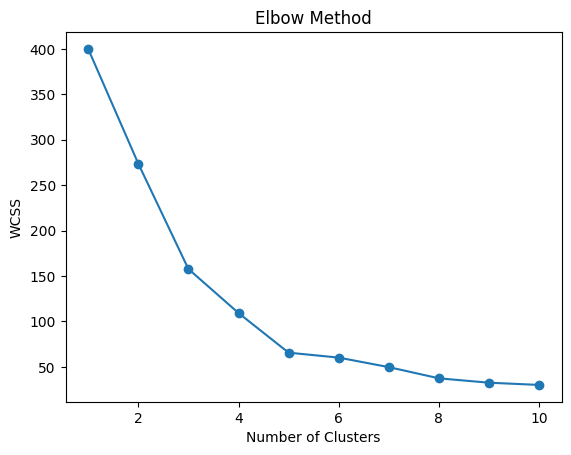

Silhouette Score: 0.5546571631111091
Davies-Bouldin Index: 0.5722356162263352


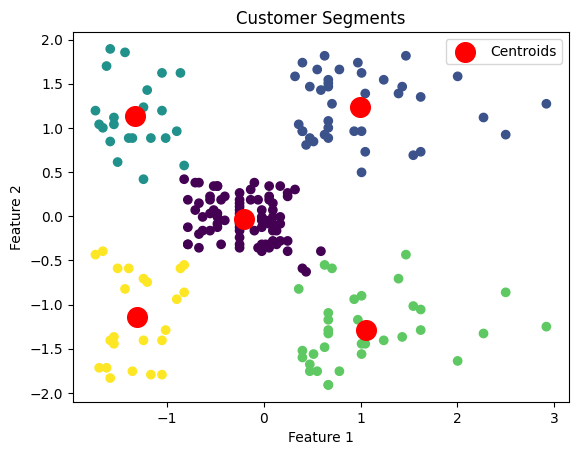

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

# -----------------------------
# STEP 1: Load Dataset
# -----------------------------
# You can replace this with your dataset file
# Example: Mall Customers dataset
data = pd.read_csv('Mall_Customers.csv')

# Select relevant features (example)
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# -----------------------------
# STEP 2: Data Preprocessing
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# STEP 3: Find Optimal Clusters (Elbow Method)
# -----------------------------
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# -----------------------------
# STEP 4: Apply K-Means
# -----------------------------
k = 5  # Choose based on elbow graph
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X_scaled)

# -----------------------------
# STEP 5: Evaluation Metrics
# -----------------------------
sil_score = silhouette_score(X_scaled, y_pred)
db_index = davies_bouldin_score(X_scaled, y_pred)

print("Silhouette Score:", sil_score)
print("Davies-Bouldin Index:", db_index)

# -----------------------------
# STEP 6: Visualization
# -----------------------------
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_pred, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='red', label='Centroids')
plt.title('Customer Segments')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()